In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
 
warnings.filterwarnings("ignore")

# ── Thai font setup ──────────────────────────────────────────
import matplotlib.font_manager as fm
plt.rcParams["font.family"] = "Tahoma"

# ── Style ────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#2e3347",
    "axes.labelcolor":  "#c8cfe0",
    "xtick.color":      "#6b7394",
    "ytick.color":      "#6b7394",
    "text.color":       "#c8cfe0",
    "grid.color":       "#2e3347",
    "grid.linewidth":   0.6,
    "font.family":      "Tahoma",
    "axes.titlesize":   11,
    "axes.labelsize":   9,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
})
ACCENT   = "#5b7cf6"
ACCENT2  = "#f26d6d"
ACCENT3  = "#43d1a0"
ACCENT4  = "#f4b942"
PALE     = "#2e3347"
PROVINCE_COLORS = {
    "Chiang Mai":  "#5b7cf6",
    "Chiang Rai":  "#f26d6d",
    "Lampang":     "#43d1a0",
    "Lamphun":     "#f4b942",
    "Mae Hong Son":"#c76bf5",
    "Nan":         "#f08050",
    "Phayao":      "#4ecde6",
    "Phrae":       "#a8e06b",
}

df = pd.read_csv(r'C:\Users\jarun\OneDrive\Desktop\pm25-early-warning-cnx\data\processed\openmeteo_firms_merged.csv')   
df.head()

,Datetime,PM25,Province,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,date,hotspot_count,frp_sum,frp_mean
0,2023-01-01 00:00:00,29.5,Chiang Mai,20.3,73,0.0,981.4,1.9,68,2023-01-01,0.0,0.0,0.0
1,2023-01-01 01:00:00,29.6,Chiang Mai,19.0,80,0.0,981.1,3.3,41,2023-01-01,0.0,0.0,0.0
2,2023-01-01 02:00:00,30.9,Chiang Mai,17.2,89,0.0,980.6,5.5,328,2023-01-01,0.0,0.0,0.0
3,2023-01-01 03:00:00,32.0,Chiang Mai,18.7,80,0.0,980.4,4.2,340,2023-01-01,0.0,0.0,0.0
4,2023-01-01 04:00:00,32.5,Chiang Mai,18.8,80,0.0,980.4,0.7,90,2023-01-01,0.0,0.0,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210432 entries, 0 to 210431
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Datetime              210432 non-null  str    
 1   PM25                  210432 non-null  float64
 2   Province              210432 non-null  str    
 3   temperature_2m        210432 non-null  float64
 4   relative_humidity_2m  210432 non-null  int64  
 5   precipitation         210432 non-null  float64
 6   surface_pressure      210432 non-null  float64
 7   wind_speed_10m        210432 non-null  float64
 8   wind_direction_10m    210432 non-null  int64  
 9   date                  210432 non-null  str    
 10  hotspot_count         210432 non-null  float64
 11  frp_sum               210432 non-null  float64
 12  frp_mean              210432 non-null  float64
dtypes: float64(8), int64(2), str(3)
memory usage: 28.2 MB


In [4]:
df.isna().sum()

Datetime                0
PM25                    0
Province                0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
surface_pressure        0
wind_speed_10m          0
wind_direction_10m      0
date                    0
hotspot_count           0
frp_sum                 0
frp_mean                0
dtype: int64

In [5]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df["year"]  = df["Datetime"].dt.year
df["month"] = df["Datetime"].dt.month
df["hour"]  = df["Datetime"].dt.hour
df["doy"]   = df["Datetime"].dt.dayofyear
df["wday"]  = df["Datetime"].dt.dayofweek

MONTH_TH = ["ม.ค.","ก.พ.","มี.ค.","เม.ย.","พ.ค.","มิ.ย.",
            "ก.ค.","ส.ค.","ก.ย.","ต.ค.","พ.ย.","ธ.ค."]
NUM_COLS  = ["PM25","temperature_2m","relative_humidity_2m","precipitation",
             "surface_pressure","wind_speed_10m","wind_direction_10m",
             "hotspot_count","frp_sum","frp_mean"]

### Summary

In [6]:
print("=" * 60)
print("  EDA SUMMARY — PM2.5 Northern Thailand 2023-2025")
print("=" * 60)
print(f"  Shape        : {df.shape}")
print(f"  Date range   : {df['Datetime'].min()} → {df['Datetime'].max()}")
print(f"  Provinces    : {df['Province'].nunique()} จังหวัด")
print(f"  Missing vals : {df.isnull().sum().sum()}")
print()
print(df[NUM_COLS].describe().round(2).to_string())
print()

  EDA SUMMARY — PM2.5 Northern Thailand 2023-2025
  Shape        : (210432, 18)
  Date range   : 2023-01-01 00:00:00 → 2025-12-31 23:00:00
  Provinces    : 8 จังหวัด
  Missing vals : 0

            PM25  temperature_2m  relative_humidity_2m  precipitation  surface_pressure  wind_speed_10m  wind_direction_10m  hotspot_count    frp_sum   frp_mean
count  210432.00       210432.00             210432.00      210432.00         210432.00       210432.00           210432.00      210432.00  210432.00  210432.00
mean       16.64           25.94                 74.62           0.22            977.44            4.73              186.26          15.86      65.87       1.93
std        12.95            4.52                 19.02           0.93              9.93            3.18               96.06          52.49     245.10       3.29
min         0.10            8.60                 13.00           0.00            948.30            0.00                1.00           0.00       0.00       0.00
25%      

In [7]:
# PM2.5 skewness / kurtosis
print(f'  PM2.5 Kurtosis : {df["PM25"].skew():.3f}')
print(f'  PM2.5 Kurtosis : {df["PM25"].kurtosis():.3f}')

with_fire = df[df["hotspot_count"] > 0]['PM25'].mean()
no_fire = df[df["hotspot_count"] == 0]['PM25'].mean()
print(f'\n Mean PM2.5 มีไฟ : {with_fire:.2f} µg/m³')
print(f' Mean PM2.5 ไม่มีไฟ : {no_fire:.2f} µg/m³')

  PM2.5 Kurtosis : 2.054
  PM2.5 Kurtosis : 8.434

 Mean PM2.5 มีไฟ : 23.37 µg/m³
 Mean PM2.5 ไม่มีไฟ : 11.29 µg/m³


In [8]:
# Autocorrelataion

cm = df[df["Province"] == "Chiang Mai"].sort_values("Datetime")["PM25"]
print('\n Autocorrelation (Chiang Mai PM2.5):')
for lag in [1, 3, 6, 12, 24]:
    corr = cm.autocorr(lag=lag)
    print(f' Lag {lag:2d}h : {cm.autocorr(lag=lag):.3f}')


 Autocorrelation (Chiang Mai PM2.5):
 Lag  1h : 0.965
 Lag  3h : 0.834
 Lag  6h : 0.644
 Lag 12h : 0.509
 Lag 24h : 0.812


### Overview

- Distribution PM2.5 (raw + log1p overlay)
- PM2.5 รายเดือน พร้อม error bar
- Diurnal pattern รายชั่วโมง
- Bar chart เปรียบเทียบรายจังหวัด


  Saved: eda_fig1_overview.png


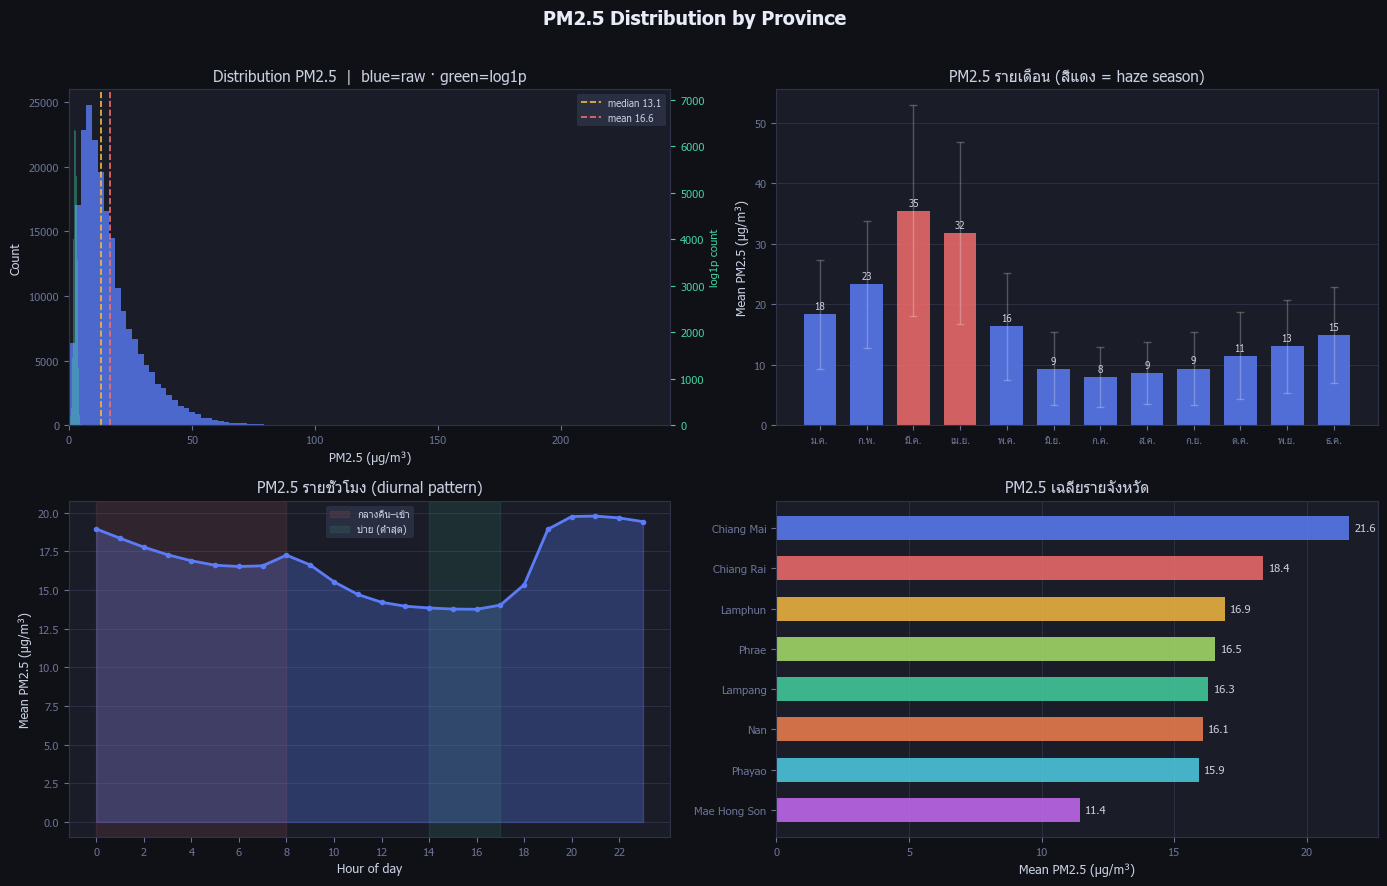

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("PM2.5 Distribution by Province", fontsize=14, color="#e8ecf8", fontweight="bold", y=0.98)

# PM2.5 Distribution + log
ax = axes[0, 0]
ax.hist(df['PM25'], bins=100, color=ACCENT, edgecolor='none', alpha=0.8)
ax2 = ax.twinx()
ax2.hist(np.log1p(df['PM25']), bins=100, color=ACCENT3, edgecolor='none', alpha=0.4)
ax2.set_ylabel("log1p count", color=ACCENT3, fontsize=8)
ax2.tick_params(colors=ACCENT3)
ax.set_xlabel("PM2.5 (µg/m³)")
ax.set_ylabel("Count")
ax.set_title("Distribution PM2.5  |  blue=raw · green=log1p")
ax.axvline(df["PM25"].median(), color=ACCENT4, lw=1.2, ls="--", label=f"median {df['PM25'].median():.1f}")
ax.axvline(df["PM25"].mean(),   color=ACCENT2, lw=1.2, ls="--", label=f"mean {df['PM25'].mean():.1f}")
ax.legend(fontsize=7, facecolor=PALE, edgecolor="none")
ax.set_xlim(0)

# PM2.5 monthly
ax = axes[0, 1]
monthly = df.groupby("month")["PM25"].agg(["mean", "std"]).reset_index()
colors_m = [ACCENT2 if m in [3, 4] else ACCENT for m in monthly["month"]]
bars = ax.bar(monthly["month"], monthly["mean"], color=colors_m, alpha=0.85, width=0.7)
ax.errorbar(monthly["month"], monthly["mean"], yerr=monthly["std"],
            fmt="none", ecolor="#ffffff40", elinewidth=1, capsize=3)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_TH, rotation=0, fontsize=7)
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("PM2.5 รายเดือน (สีแดง = haze season)")
ax.yaxis.grid(True); ax.set_axisbelow(True)
for bar, val in zip(bars, monthly["mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.0f}", ha="center", va="bottom", fontsize=7, color="#c8cfe0")

# PM2.5 by hour
ax = axes[1, 0]
hourly = df.groupby("hour")["PM25"].mean()
ax.fill_between(hourly.index, hourly.values, alpha=0.3, color=ACCENT)
ax.plot(hourly.index, hourly.values, color=ACCENT, lw=2, marker="o", ms=3)
ax.axvspan(0, 8,   alpha=0.1, color=ACCENT2, label="กลางคืน–เช้า")
ax.axvspan(14, 17, alpha=0.1, color=ACCENT3, label="บ่าย (ต่ำสุด)")
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("PM2.5 รายชั่วโมง (diurnal pattern)")
ax.legend(fontsize=7, facecolor=PALE, edgecolor="none")
ax.yaxis.grid(True); ax.set_axisbelow(True)
 
# PM2.5 by province
ax = axes[1, 1]
prov = df.groupby("Province")["PM25"].mean().sort_values(ascending=True)
colors_p = [PROVINCE_COLORS.get(p, ACCENT) for p in prov.index]
bars = ax.barh(prov.index, prov.values, color=colors_p, alpha=0.85, height=0.6)
ax.set_xlabel("Mean PM2.5 (µg/m³)")
ax.set_title("PM2.5 เฉลี่ยรายจังหวัด")
ax.xaxis.grid(True); ax.set_axisbelow(True)
for bar, val in zip(bars, prov.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=8)
 
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_fig1_overview.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("\n  Saved: eda_fig1_overview.png")
plt.show()

### Features & Correlations

- Correlation heatmap ทุก feature
- Bar chart correlation กับ PM2.5
- Scatter: log(hotspot) vs PM2.5
- Heatmap จังหวัด × เดือน + Autocorrelation bars

  Saved: eda_fig2_features.png


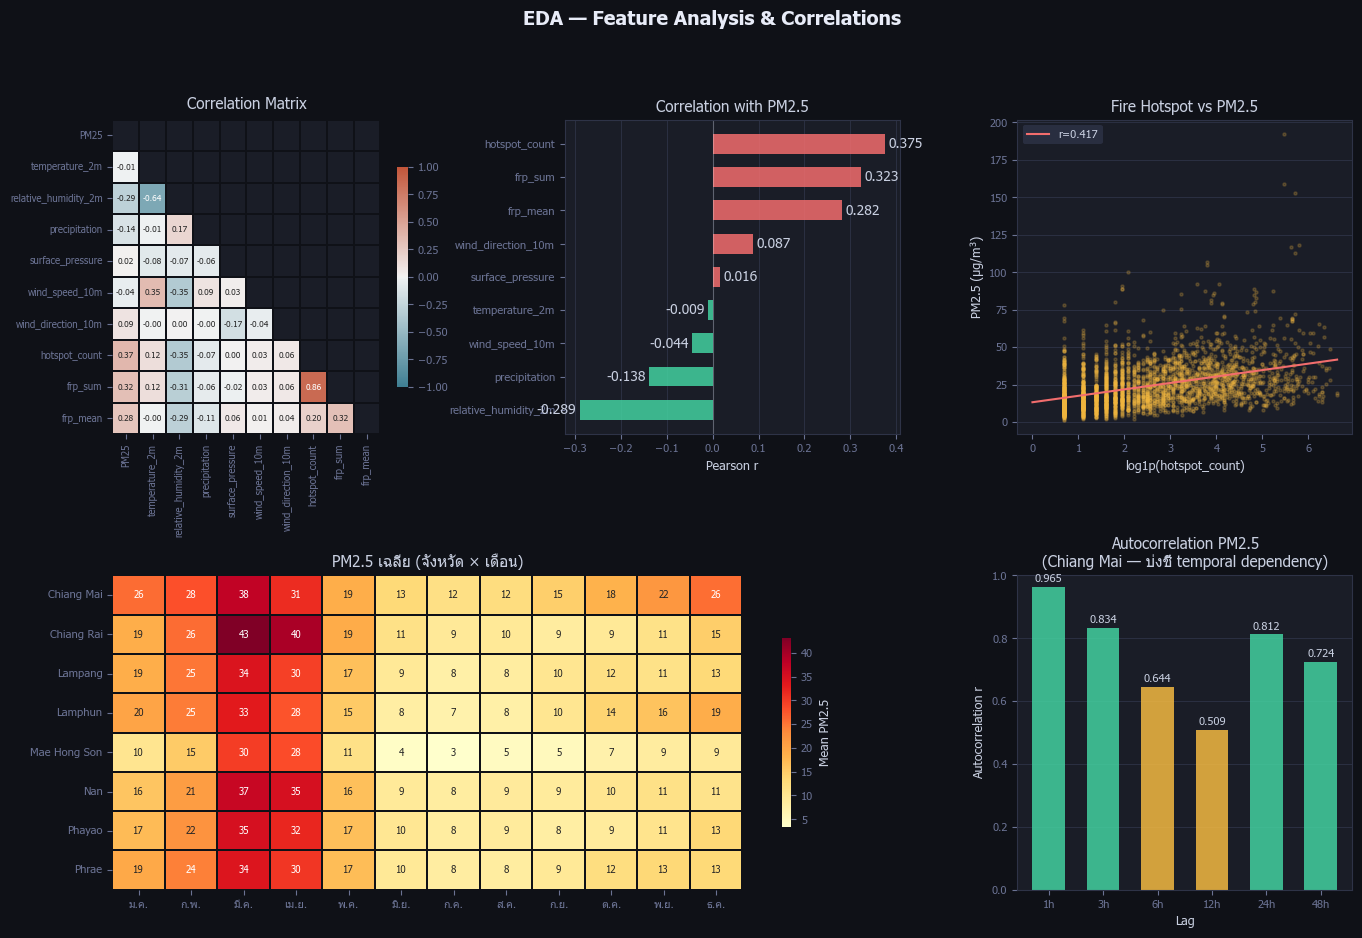

In [12]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("EDA — Feature Analysis & Correlations", fontsize=14,
             color="#e8ecf8", fontweight="bold", y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Correlation heatmap
ax = fig.add_subplot(gs[0, 0])
corr = df[NUM_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, ax=ax, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={'size': 6}, linewidths=0.3, linecolor="#0f1117", cbar_kws={"shrink": 0.7})
ax.set_title("Correlation Matrix", pad=8)
ax.tick_params(labelsize=7)

# Feature correlation with PM2.5 (bar)
ax = fig.add_subplot(gs[0, 1])
pm_corr = df[NUM_COLS].corrwith(df["PM25"]).drop("PM25").sort_values()
colors_c = [ACCENT2 if v > 0 else ACCENT3 for v in pm_corr.values]
bars = ax.barh(pm_corr.index, pm_corr.values, color=colors_c, alpha=0.85, height=0.6)
ax.axvline(0, color="#ffffff40", lw=0.8)
ax.set_xlabel("Pearson r")
ax.set_title("Correlation with PM2.5")
ax.xaxis.grid(True); ax.set_axisbelow(True)
for bar, val in zip(bars, pm_corr.values):
    x = val + 0.008 if val >= 0 else val - 0.008
    ha = 'left' if val >= 0 else 'right'
    ax.text(x, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha=ha)

# hotspot_count vs PM2.5
ax = fig.add_subplot(gs[0, 2])
sample = df[df['hotspot_count'] > 0].sample(3000, random_state=42)
ax.scatter(np.log1p(sample["hotspot_count"]), sample["PM25"],
           alpha=0.2, s=5, color=ACCENT4, rasterized=True)

#Trend line
m, b, r, p , _ = stats.linregress(np.log1p(sample['hotspot_count']), sample['PM25'])
xr = np.linspace(0, np.log1p(sample['hotspot_count']).max(), 100)
ax.plot(xr, m * xr + b, color= ACCENT2, lw=1.5, label=f'r={r:.3f}')
ax.set_xlabel("log1p(hotspot_count)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Fire Hotspot vs PM2.5")
ax.legend(fontsize=8, facecolor=PALE, edgecolor="none")
ax.yaxis.grid(True); ax.set_axisbelow(True)

# Box: PM2.5 by month per province (heatmap)
ax = fig.add_subplot(gs[1, :2])
piv = df.groupby(['Province', 'month'])['PM25'].mean().unstack()
piv.columns = MONTH_TH
sns.heatmap(piv, ax=ax, cmap="YlOrRd", annot=True, fmt='.0f', annot_kws={'size': 7}, linewidths=0.3, linecolor="#0f1117", cbar_kws={"shrink": 0.6, "label": "Mean PM2.5"})
ax.set_title("PM2.5 เฉลี่ย (จังหวัด × เดือน)")
ax.set_ylabel("")
ax.tick_params(labelsize=8)
 
 # Autocorrelation
ax = fig.add_subplot(gs[1, 2])
lags = [1, 3, 6, 12, 24, 48]
ac_vals = [cm.autocorr(lag=lag) for lag in lags]
colors_a = [ACCENT3 if v > 0.7 else ACCENT4 if v > 0.5 else ACCENT for v in ac_vals]
bars = ax.bar([str(lag) + 'h' for lag in lags], ac_vals, color=colors_a, alpha=0.85, width=0.6)
ax.set_ylim(0, 1)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation r")
ax.set_title("Autocorrelation PM2.5\n(Chiang Mai — บ่งชี้ temporal dependency)")
ax.yaxis.grid(True); ax.set_axisbelow(True)
for bar, val in zip(bars, ac_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)
plt.savefig("eda_fig2_features.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("  Saved: eda_fig2_features.png")
plt.show()






### Temporal Deep Dive

- Line chart รายเดือน แยกปี 2023/24/25
- Violin plot รายจังหวัด
- Heatmap extreme events (PM2.5 > 100)
- Heatmap ชั่วโมง × เดือน

  Saved: eda_fig3_temporal.png


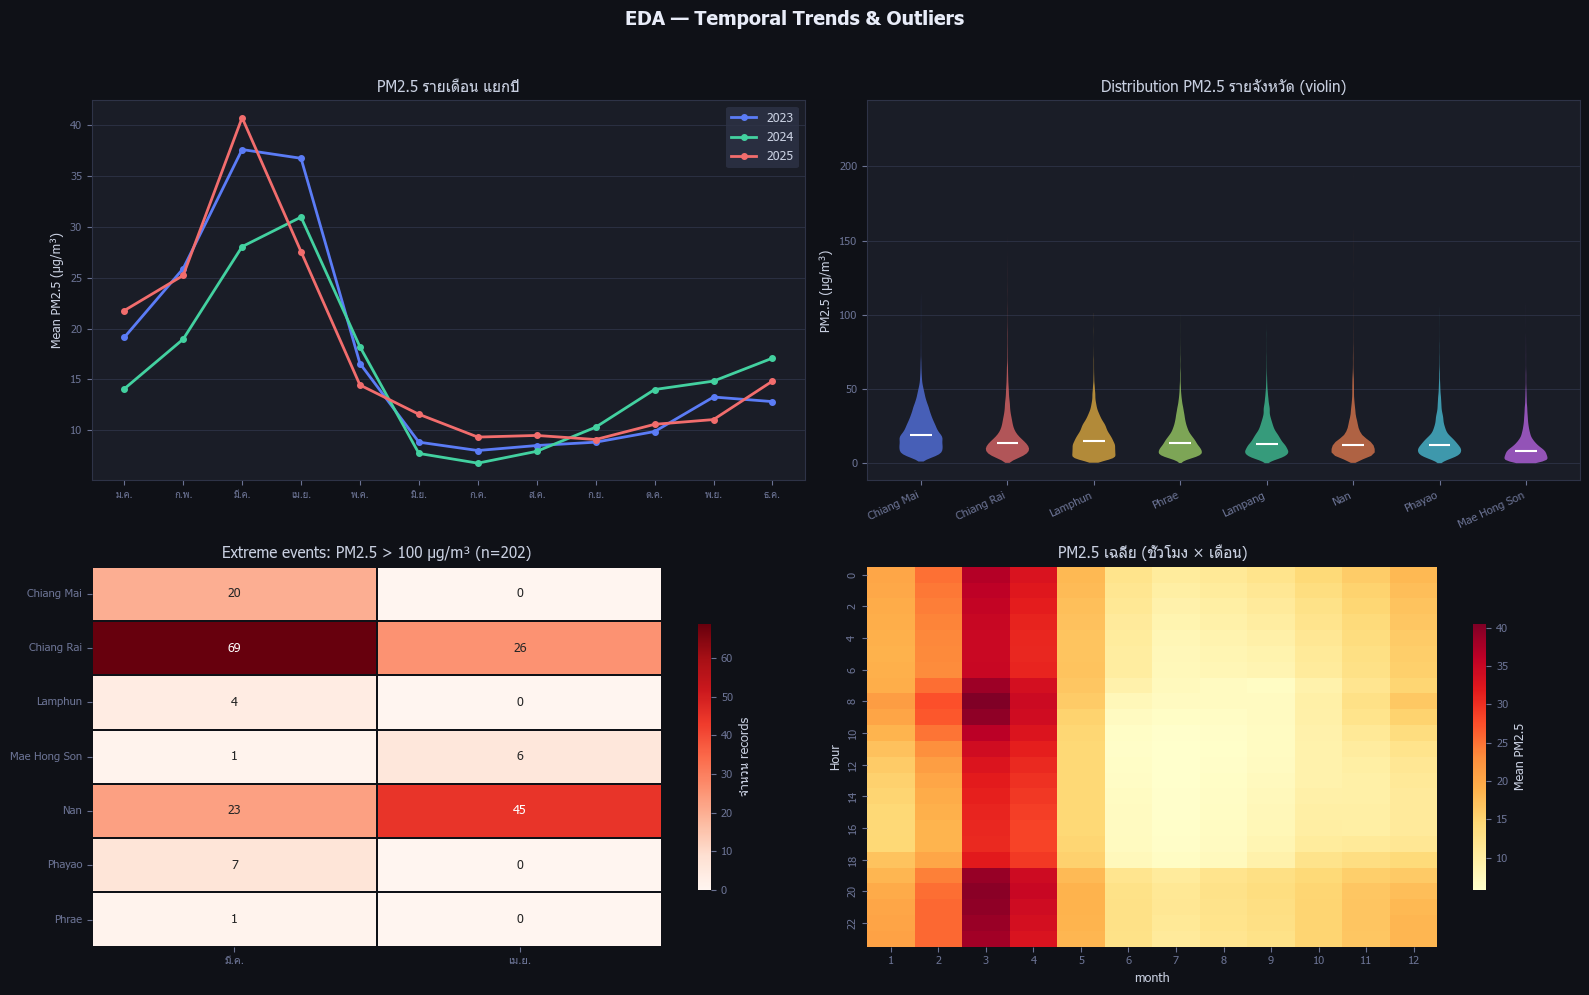

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("EDA — Temporal Trends & Outliers", fontsize=14, color="#e8ecf8", fontweight="bold", y=0.99)

# Monthly mean per year — line chart
ax = axes[0, 0]
for yr, color in zip([2023, 2024, 2025], [ACCENT, ACCENT3, ACCENT2]):
    m = df[df['year'] == yr].groupby('month')['PM25'].mean()
    ax.plot(m.index, m.values, color=color, lw=2, marker='o', ms=4, label=str(yr))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_TH, rotation=0, fontsize=7)
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("PM2.5 รายเดือน แยกปี")
ax.legend(fontsize=9, facecolor=PALE, edgecolor="none")
ax.yaxis.grid(True); ax.set_axisbelow(True)

# PM2.5 By Province - Violin plot
ax = axes[0, 1]
order = df.groupby("Province")["PM25"].mean().sort_values(ascending=False).index
data_by_prov = [df[df['Province'] == p]['PM25'] for p in order]

order = df.groupby("Province")["PM25"].mean().sort_values(ascending=False).index
data_by_prov = [df[df['Province'] == p]['PM25'] for p in order]
parts = ax.violinplot(data_by_prov, positions=range(len(order)), showmedians=True, showextrema=False)

for i, (pc, prov) in enumerate(zip(parts["bodies"], order)):
    pc.set_facecolor(PROVINCE_COLORS.get(prov, ACCENT))
    pc.set_alpha(0.7)
parts["cmedians"].set_color("#ffffff")
parts["cmedians"].set_linewidth(1.5)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=25, ha="right", fontsize=8)
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Distribution PM2.5 รายจังหวัด (violin)")
ax.yaxis.grid(True); ax.set_axisbelow(True)

# PM2.5 > 100 Heatmap (outliers)
ax = axes[1, 0]
out = df[df['PM25'] > 100]
out_piv = out.groupby(['Province', 'month']).size().unstack(fill_value=0)
out_piv.columns = [MONTH_TH[m-1] for m in out_piv.columns]
if not out_piv.empty:
    sns.heatmap(out_piv, ax=ax, cmap="Reds", annot=True, fmt="d",
                annot_kws={"size": 9}, linewidths=0.3, linecolor="#0f1117",
                cbar_kws={"shrink": 0.7, "label": "จำนวน records"})
ax.set_title(f"Extreme events: PM2.5 > 100 µg/m³ (n={len(out)})")
ax.set_ylabel("")

# hour × month mean PM2.5 (heatmap)
ax = axes[1, 1]
hm_data = df.groupby(['hour', 'month'])['PM25'].mean().unstack()
hm_data_columns = MONTH_TH
sns.heatmap(hm_data, ax=ax, cmap="YlOrRd",
            linewidths=0, cbar_kws={"shrink": 0.7, "label": "Mean PM2.5"},
            xticklabels=True, yticklabels=2)
ax.set_title("PM2.5 เฉลี่ย (ชั่วโมง × เดือน)")
ax.set_ylabel("Hour")
ax.tick_params(labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_fig3_temporal.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("  Saved: eda_fig3_temporal.png")
plt.show()

# Feature Engineering Preview

- เปรียบ raw vs log1p ทั้ง PM2.5 และ hotspot_count
- Scatter lag-1 (r = 0.965)
- Feature correlation เมื่อ include lag features แล้ว

In [1]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("EDA — Feature Engineering Preview", fontsize=14,
             color="#e8ecf8", fontweight="bold", y=0.99)

# log1p transfor, comparison
ax = axes[0, 0]
ax.hist(df['PM25'], bins=80, color=ACCENT, alpha=0.6, label='raw PM2.5', density=True)
ax.hist(np.expm1(np.log1p(df['PM25'])), bins=80, color=ACCENT3, alpha=0.4, label="exp(log1p) — same", density=True)
ax2 = ax.twinx()
ax2.hist(np.log1p(df['PM25']), bins=80, color=ACCENT3, alpha=0.5, label="log1p PM2.5", density=True)
ax2.set_ylabel("log1p density", color=ACCENT3, fontsize=8)
ax2.tick_params(colors=ACCENT3)
ax.set_xlabel("PM2.5")
ax.set_ylabel("Density")
ax.set_title("Raw vs log1p PM2.5  →  ลด skewness")
ax.legend(fontsize=7, facecolor=PALE, edgecolor="none", loc="upper right")

# PM2.5 lag-1 scatter
ax = axes[0, 1]
cm_full = df[df['Province'] == 'Chiang Mai'].sort_values('Datetime')['PM25']
lag_df = pd.DataFrame({
    't':cm_full.values[1:],
    't-1':cm_full.values[:-1]
})
sample_lag = lag_df.sample(4000, random_state=42)
ax.scatter(sample_lag['t-1'], sample_lag['t'], alpha=0.15, s=5, color=ACCENT4, rasterized=True)
m, b, r, p , _ = stats.linregress(sample_lag['t-1'], sample_lag['t'])
xr = np.linspace(sample_lag['t-1'].min(), sample_lag['t-1'].max(), 100)
ax.plot(xr, m * xr + b, color=ACCENT2, lw=1.5, label=f"r={r:.3f}")
ax.set_xlabel("PM2.5 (t-1)")
ax.set_ylabel("PM2.5 (t)")
ax.set_title("Lag-1 feature (Chiang Mai) — r = 0.965")
ax.legend(fontsize=8, facecolor=PALE, edgecolor="none")
ax.yaxis.grid(True); ax.xaxis.grid(True); ax.set_axisbelow(True)

# hotspot log transform
ax = axes[1, 0]
ax.hist(df["hotspot_count"][df["hotspot_count"] > 0], bins=80,
        color=ACCENT2, alpha=0.7, label="hotspot_count (>0)", density=True)
ax2 = ax.twinx()
ax2.hist(np.log1p(df["hotspot_count"][df["hotspot_count"] > 0]),
         bins=80, color=ACCENT3, alpha=0.5, label="log1p", density=True)
ax2.set_ylabel("log1p density", color=ACCENT3, fontsize=8)
ax2.tick_params(colors=ACCENT3)
ax.set_xlabel("hotspot_count")
ax.set_ylabel("Density")
ax.set_title("hotspot_count: raw vs log1p  →  ควร transform")
ax.legend(fontsize=7, facecolor=PALE, edgecolor="none")

# Suggested Feature importance (correlation based preview)
ax = axes[1, 1]
# lag feature on Chiang Mai
cm_df = df[df['Province'] == 'Chiang Mai'].sort_values('Datetime').copy()
for lag in [1, 2, 3, 6, 12, 24]:
    cm_df[f'pm25_lag_{lag}h'] = cm_df['PM25'].shift(lag)
cm_df["log_hotspot"]   = np.log1p(cm_df["hotspot_count"])
cm_df["log_frp_sum"]   = np.log1p(cm_df["frp_sum"])
cm_df["is_haze_season"] = cm_df["month"].isin([3, 4]).astype(int)
cm_df = cm_df.dropna()

feat_cols = ["pm25_lag_1h", "pm25_lag_2h", "pm25_lag_3h", "pm25_lag_6h",
             "pm25_lag_12h", "pm25_lag_24h",
             "log_hotspot", "log_frp_sum", "relative_humidity_2m",
             "precipitation", "temperature_2m", "wind_speed_10m",
             "is_haze_season", "hour", "month"]
feat_corr = cm_df[feat_cols + ["PM25"]].corr()["PM25"].drop("PM25").abs().sort_values(ascending=True)
colors_f = [ACCENT3 if 'lag' in c else (ACCENT2 if 'log' in c else ACCENT) for c in feat_corr.index]
ax.barh(feat_corr.index, feat_corr.values, color=colors_f, alpha=0.85, height=0.65)
ax.set_xlabel("|Pearson r| กับ PM2.5")
ax.set_title("Feature correlation preview\n(Chiang Mai — green=lag, red=fire, blue=weather)")
ax.xaxis.grid(True); ax.set_axisbelow(True)
for i, (idx, val) in enumerate(feat_corr.items()):
    ax.text(val + 0.005, i, f"{val:.3f}", va="center", fontsize=7)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_fig4_feature_eng.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("  Saved: eda_fig4_feature_eng.png")
plt.show()
 
print("\n" + "=" * 60)
print("  EDA เสร็จสมบูรณ์ — ไฟล์ที่ได้:")
print("    eda_fig1_overview.png")
print("    eda_fig2_features.png")
print("    eda_fig3_temporal.png")
print("    eda_fig4_feature_eng.png")
print("=" * 60)


NameError: name 'plt' is not defined

สรุป EDA: Dataset PM2.5 ภาคเหนือ 2023–2025
ภาพรวมข้อมูล
Dataset มี 210,432 records ครอบคลุม 8 จังหวัดภาคเหนือ (เชียงใหม่ เชียงราย ลำปาง ลำพูน แม่ฮ่องสอน น่าน พะเยา แพร่) ในรูปแบบ hourly data ตั้งแต่ 1 ม.ค. 2023 ถึง 31 ธ.ค. 2025 แต่ละจังหวัดมี 26,304 records เท่ากันพอดี และไม่มี missing values เลย ซึ่งถือว่าหายากมากสำหรับ real-world dataset

Target Variable: PM2.5
ค่าเฉลี่ยอยู่ที่ 16.6 µg/m³ (std = 12.9) ค่าสูงสุดที่ 232.8 µg/m³ พบที่จังหวัดน่านในเดือนเมษายน การกระจายตัวมี skewness สูงมาก (2.05) และ kurtosis = 8.4 แสดงว่าข้อมูลไม่ได้กระจายแบบ normal แต่มี long right tail เมื่อจัดหมวดตามเกณฑ์ US EPA พบว่า Good + Moderate รวมกัน 91.4% แต่ก็มี extreme values ที่ต้องระวัง สำหรับการ train model ควรพิจารณา log1p transform ก่อน เพราะจะทำให้ distribution สมมาตรขึ้นมากและช่วยให้ model เรียนรู้ได้ดีขึ้น

Pattern ที่สำคัญที่สุด 3 อย่าง
1. Seasonal (รายเดือน) — ชัดเจนที่สุด มีนาคม–เมษายนคือ haze season ค่าเฉลี่ยพุ่งสูงถึง 35.5 และ 31.8 µg/m³ ตามลำดับ ซึ่งสูงกว่าเดือนอื่นเกือบ 4 เท่า (เดือนอื่น ๆ อยู่ที่ 8–18 µg/m³) feature is_haze_season หรือ month จึงจำเป็นมาก
2. Diurnal (รายชั่วโมง) — PM2.5 สูงช่วงกลางคืนถึงเช้าตรู่ (19:00–08:00) และต่ำสุดช่วงบ่าย (14:00–16:00) เป็น planetary boundary layer effect ที่เกิดเพราะอากาศเย็นตอนกลางคืนกดมลพิษไว้ชั้นล่าง feature hour ควรใส่เข้าโมเดล
3. Spatial (รายจังหวัด) — เชียงใหม่ค่าเฉลี่ยสูงสุด (21.6) แม่ฮ่องสอนต่ำสุด (11.4) ทั้งที่ติดชายแดนพม่าเหมือนกัน น่าจะมาจาก geography ที่ระบายอากาศต่างกัน Province ต้องเป็น feature เสมอ

Fire Features — ตัวแปรที่สำคัญที่สุด
hotspot_count มี correlation กับ PM2.5 สูงสุดในกลุ่ม weather/fire features ที่ r = 0.375 และเมื่อมีไฟ (hotspot > 0) PM2.5 เฉลี่ยอยู่ที่ 23.4 µg/m³ เทียบกับ 11.3 µg/m³ เมื่อไม่มีไฟ ต่างกันเกือบ 2 เท่า อย่างไรก็ตาม hotspot_count มี distribution skewed มากและมีค่า 0 ถึง 55.7% ของ records ทั้งหมด ควรทำ log1p transform ก่อนนำไปใช้
ฝั่ง weather features humidity มี correlation ลบ (r = -0.289) และ precipitation ลบ (r = -0.138) สอดคล้อง domain knowledge ว่าฝนและความชื้นช่วยล้างฝุ่น ส่วน temperature และ wind_speed มี correlation ต่ำมาก (ไม่ถึง 0.05 ในเชิงบวก) แต่ไม่ควรตัดทิ้งเพราะอาจมี nonlinear relationship

Temporal Dependency — จุดที่ critical ที่สุดสำหรับ modeling
Autocorrelation ของ PM2.5 สูงมาก โดย lag 1h = 0.965 และ lag 24h = 0.812 ซึ่งหมายความว่า PM2.5 ชั่วโมงก่อนหน้าเป็น predictor ที่ดีที่สุดของชั่วโมงปัจจุบัน เมื่อเพิ่ม lag features เข้าไป correlation พุ่งขึ้นมากกว่า feature อื่นทั้งหมด นี่คือจุดที่ต้องระวังเรื่อง data leakage ในการ split train/test ต้องใช้ time-based split เท่านั้น ห้ามใช้ random split เด็ดขาด

Extreme Events
มีทั้งหมด 202 records ที่ PM2.5 > 100 µg/m³ คิดเป็น 0.1% ของข้อมูล กระจุกตัวที่เชียงราย–น่านในเดือนมี.ค.–เม.ย. เกือบทั้งหมด model มักจะ underperform ในกลุ่มนี้เพราะ training data ไม่สมดุล อาจพิจารณา weighted loss หรือ oversampling ช่วง haze season

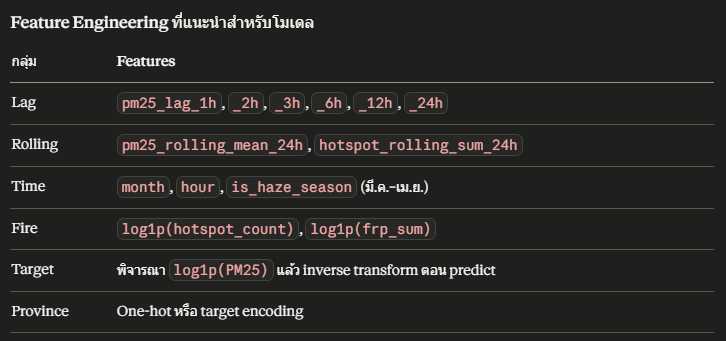